# Validation of a Gamified Selective Attention Task
This notebook processes the raw experimental data and generates all visualizations required for the comprehensive report.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import re
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Helper Functions
def parse_list_str(s):
    if pd.isna(s) or s == 'NaN' or not isinstance(s, str): return []
    try: return ast.literal_eval(s)
    except: return []

def get_first_val(lst):
    return lst[0] if len(lst) > 0 else np.nan

def extract_phone_coords(coord_str):
    if pd.isna(coord_str): return []
    pairs = re.findall(r'\(([-+]?\d*\.?\d+),\s*([-+]?\d*\.?\d+)\)', str(coord_str))
    return [(float(x), float(y)) for x, y in pairs]

## Data Loading & Preparation
Loading the 4 raw CSV files and combining them into a unified format for 2x2 mixed factorial analysis.

In [2]:
# Load files
df_sp = pd.read_csv('single_phone_combined.csv')
df_mp = pd.read_csv('multiple_phone_combined.csv')
df_sl = pd.read_csv('single_lab_combined.csv')
df_ml = pd.read_csv('multiple_lab_combined.csv')

# Phone data preparation
df_sp['Modality'] = 'Game'
df_sp['Load'] = 'Single'
df_mp['Modality'] = 'Game'
df_mp['Load'] = 'Multiple'
df_phone = pd.concat([df_sp, df_mp], ignore_index=True)

# Lab data preparation
df_sl['rt_list'] = df_sl['mouse.time'].apply(parse_list_str)
df_sl['RT'] = df_sl['rt_list'].apply(get_first_val) * 1000
df_sl['Level'] = df_sl['trials.thisN'].fillna(df_sl.get('thisN', 0)) + 1
df_sl['Modality'] = 'Lab'
df_sl['Load'] = 'Single'

df_ml['rt_list'] = df_ml['click_times'].apply(parse_list_str)
df_ml['RT'] = df_ml['rt_list'].apply(get_first_val) * 1000
df_ml['Level'] = df_ml['trials.thisN'] + 1
df_ml['Modality'] = 'Lab'
df_ml['Load'] = 'Multiple'

# Clean dataframes
df_sp_clean = df_sp[['Level', 'InitialResponseTime(ms)', 'Modality', 'Load']].rename(columns={'InitialResponseTime(ms)': 'RT'})
df_mp_clean = df_mp[['Level', 'InitialResponseTime(ms)', 'Modality', 'Load']].rename(columns={'InitialResponseTime(ms)': 'RT'})
df_sl_clean = df_sl[['Level', 'RT', 'Modality', 'Load']].dropna(subset=['RT', 'Level'])
df_ml_clean = df_ml[['Level', 'RT', 'Modality', 'Load']].dropna(subset=['RT', 'Level'])

# Combine all and trim outliers
df_all = pd.concat([df_sp_clean, df_mp_clean, df_sl_clean, df_ml_clean], ignore_index=True)
df_all = df_all[df_all['RT'] < 10000] # Standard outlier trim

plt.style.use('ggplot')
sns.set_context('talk')

## Statistical & Trend Plots
Visualizing Reaction Times across levels, conditions, and modalities to directly address RQ2 and RQ3.

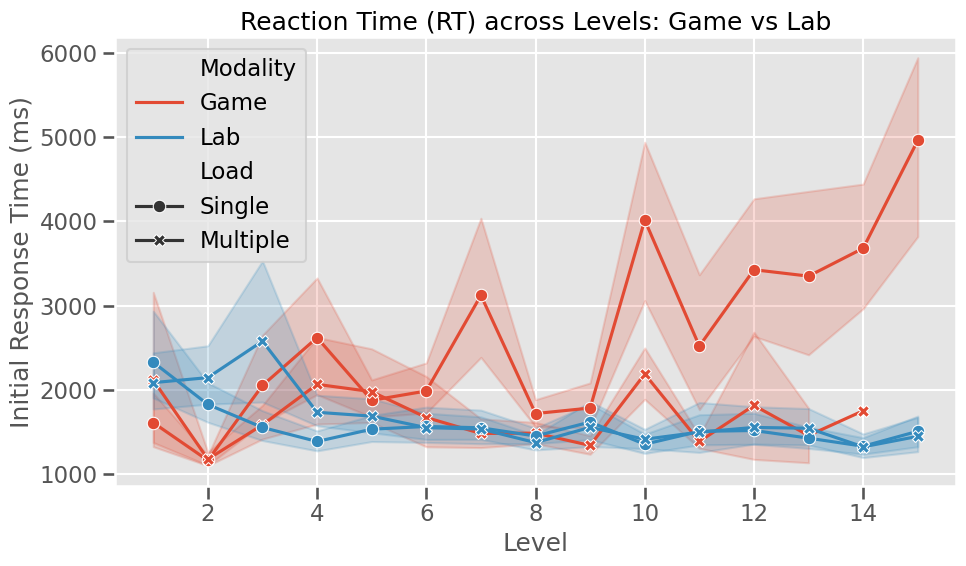

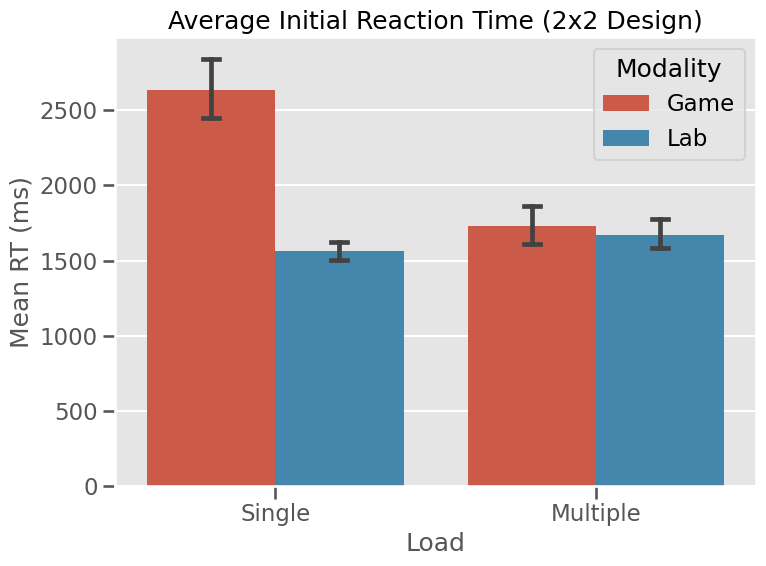

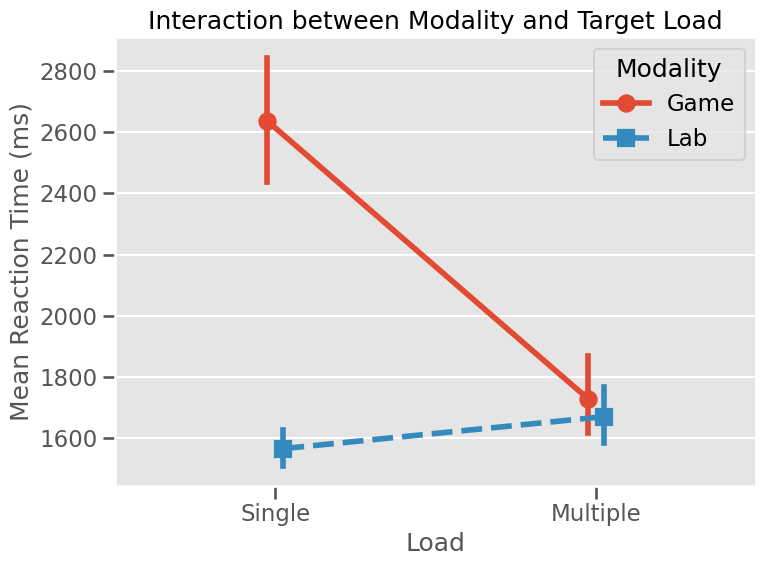

In [3]:
# 1. RT across Levels
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_all, x='Level', y='RT', hue='Modality', style='Load', markers=True, dashes=False)
plt.title('Reaction Time (RT) across Levels: Game vs Lab')
plt.ylabel('Initial Response Time (ms)')
plt.tight_layout()
plt.show()

# 2. Average RT by Cell
plt.figure(figsize=(8, 6))
sns.barplot(data=df_all, x='Load', y='RT', hue='Modality', errorbar='ci', capsize=.1)
plt.title('Average Initial Reaction Time (2x2 Design)')
plt.ylabel('Mean RT (ms)')
plt.tight_layout()
plt.show()

# 3. Interaction Plot
plt.figure(figsize=(8, 6))
sns.pointplot(data=df_all, x='Load', y='RT', hue='Modality', markers=['o', 's'], linestyles=['-', '--'], dodge=True)
plt.title('Interaction between Modality and Target Load')
plt.ylabel('Mean Reaction Time (ms)')
plt.tight_layout()
plt.show()

## Spatial Analysis & Heatmaps
Visualizing "Danger Zones" and search concentration to address RQ4.

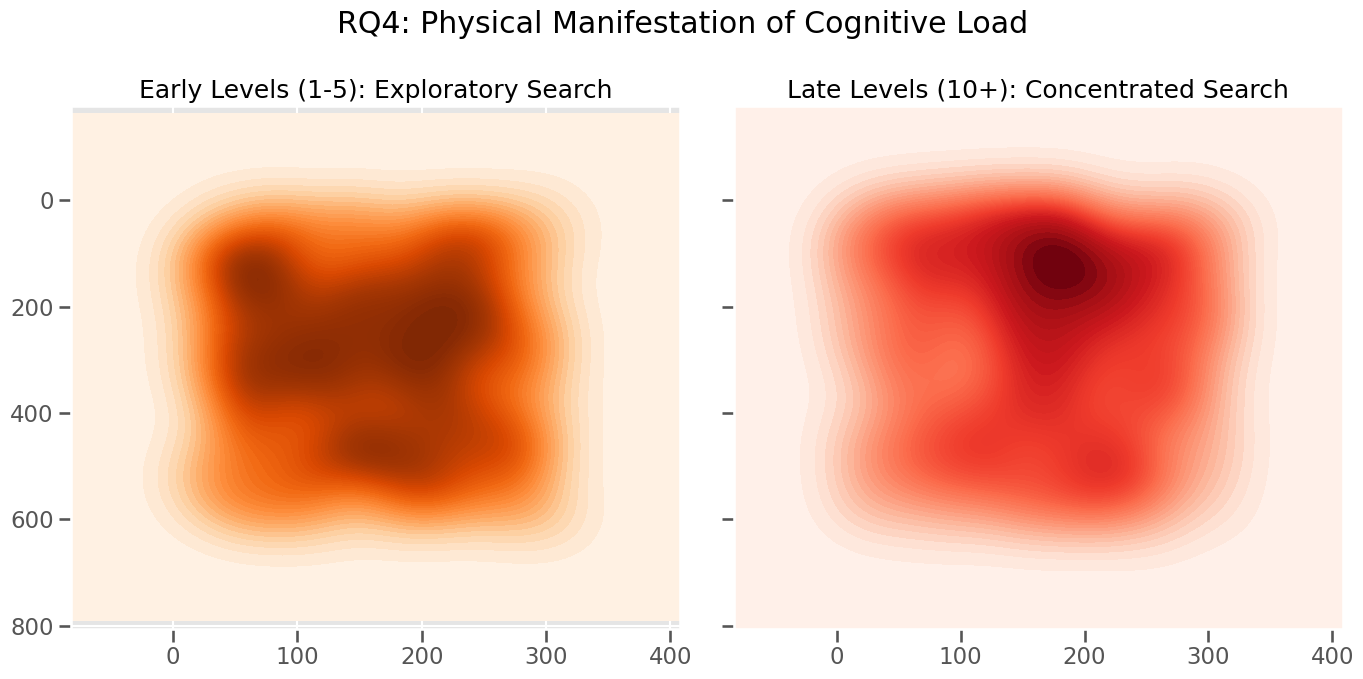

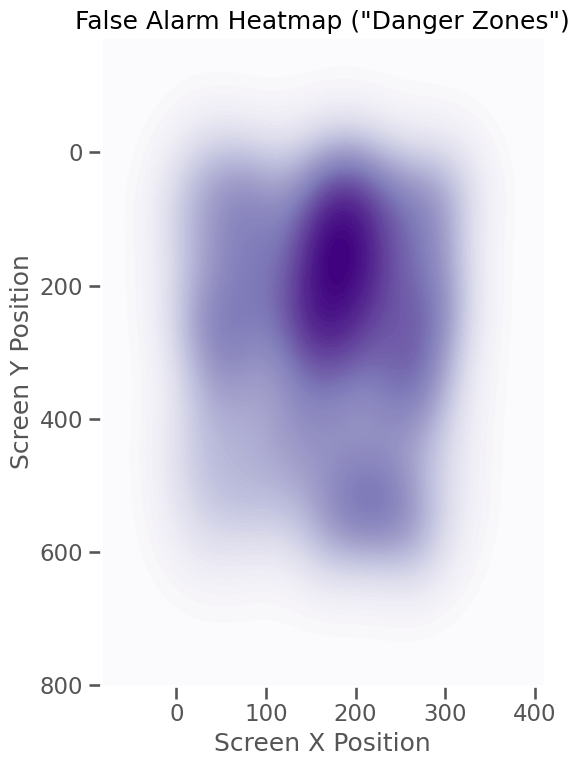

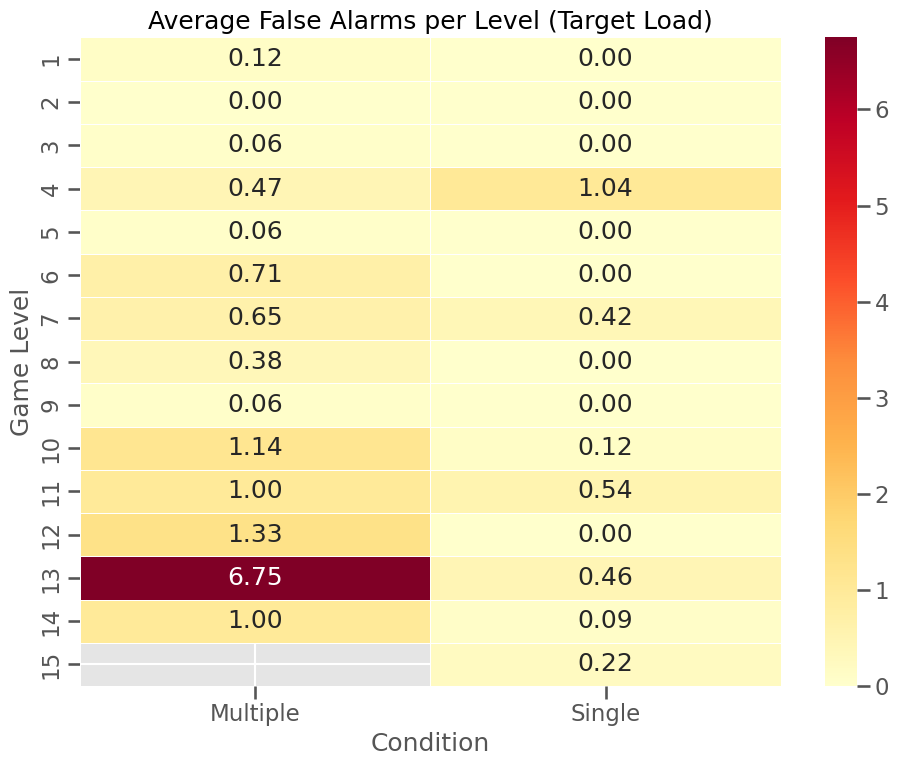

In [4]:
# Level-specific spatial split
early = df_phone[df_phone['Level'] <= 5]
late = df_phone[df_phone['Level'] >= 10]

def get_coords(df):
    xs, ys = [], []
    for s in df['HitPositions(x,y)']:
        for x, y in extract_phone_coords(s):
            xs.append(x); ys.append(y)
    return xs, ys

e_x, e_y = get_coords(early)
l_x, l_y = get_coords(late)

# Early vs Late Heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharey=True)
sns.kdeplot(x=e_x, y=e_y, fill=True, cmap='Oranges', ax=axes[0], levels=50, thresh=0)
axes[0].set_title('Early Levels (1-5): Exploratory Search')
axes[0].invert_yaxis()

sns.kdeplot(x=l_x, y=l_y, fill=True, cmap='Reds', ax=axes[1], levels=50, thresh=0)
axes[1].set_title('Late Levels (10+): Concentrated Search')

plt.suptitle('RQ4: Physical Manifestation of Cognitive Load')
plt.tight_layout()
plt.show()

# Error-Weighted Heatmap (Danger Zones)
err_x, err_y, weights = [], [], []
for i, row in df_phone.iterrows():
    coords = extract_phone_coords(row['HitPositions(x,y)'])
    fa = row['FalseAlarms']
    if fa > 0:
        for x, y in coords:
            err_x.append(x)
            err_y.append(y)
            weights.append(fa)

if err_x:
    plt.figure(figsize=(6, 8))
    sns.kdeplot(x=err_x, y=err_y, weights=weights, fill=True, cmap='Purples', levels=100, thresh=0)
    plt.title('False Alarm Heatmap ("Danger Zones")')
    plt.xlabel('Screen X Position')
    plt.ylabel('Screen Y Position')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

# Heatmap Error Rate Table
plt.figure(figsize=(10, 8))
pivot_err = df_phone.groupby(['Level', 'Load'])['FalseAlarms'].mean().unstack()
sns.heatmap(pivot_err, annot=True, cmap='YlOrRd', fmt='.2f', linewidths=.5)
plt.title('Average False Alarms per Level (Target Load)')
plt.ylabel('Game Level')
plt.xlabel('Condition')
plt.tight_layout()
plt.show()